In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest


In [83]:
# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Drop ID columns
df.drop(columns=["UDI", "Product ID"], inplace=True)

# Convert target to binary
df['Machine failure'] = df['Machine failure'].astype(int)

# One-hot encode categorical
df = pd.get_dummies(df, drop_first=True)


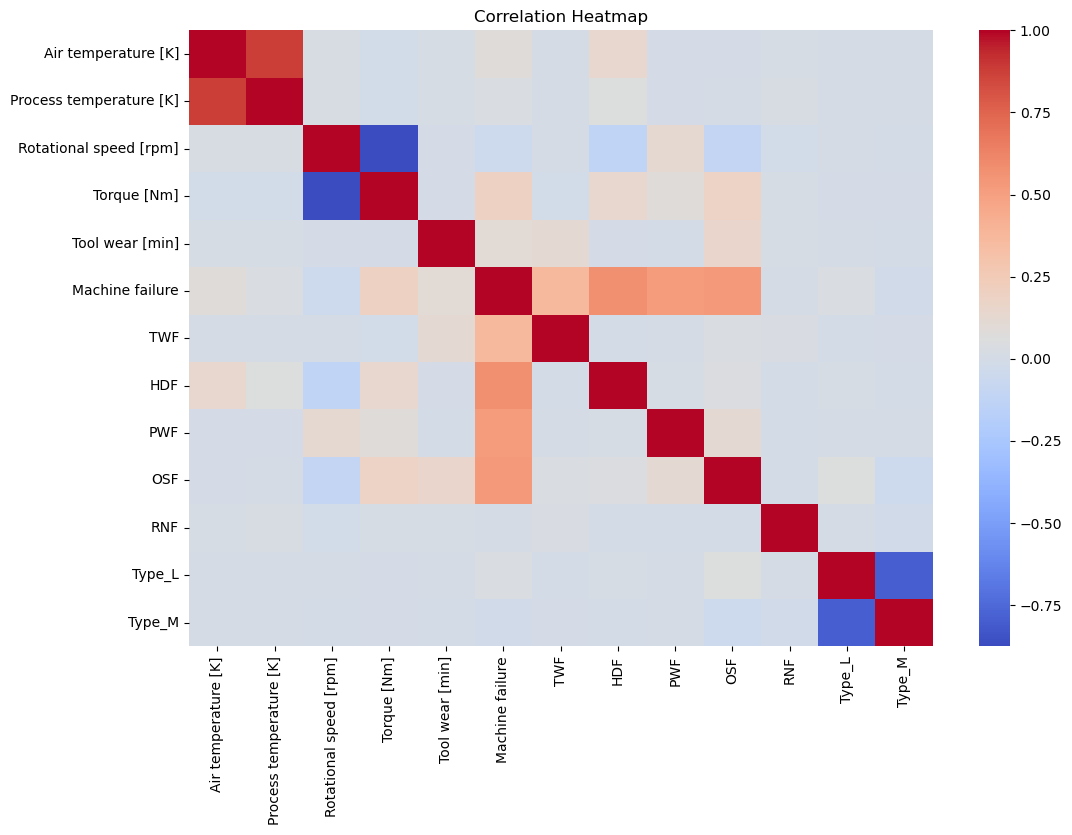

In [84]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


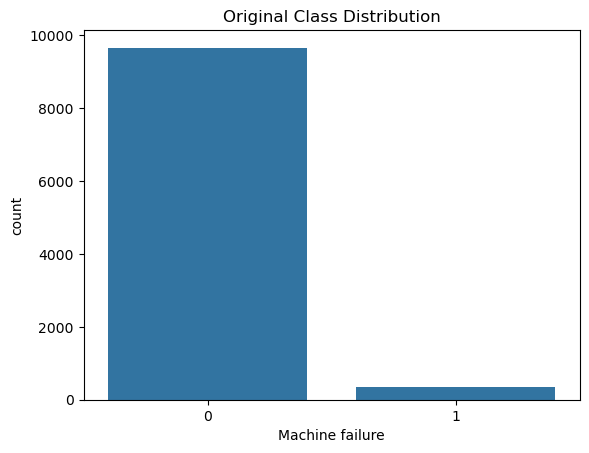

In [85]:
sns.countplot(x='Machine failure', data=df)
plt.title("Original Class Distribution")
plt.show()


In [86]:
iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(df.drop(columns=["Machine failure"]))
df_clean = df[outliers == 1]


In [87]:
X = df_clean.drop("Machine failure", axis=1)
y = df_clean["Machine failure"]


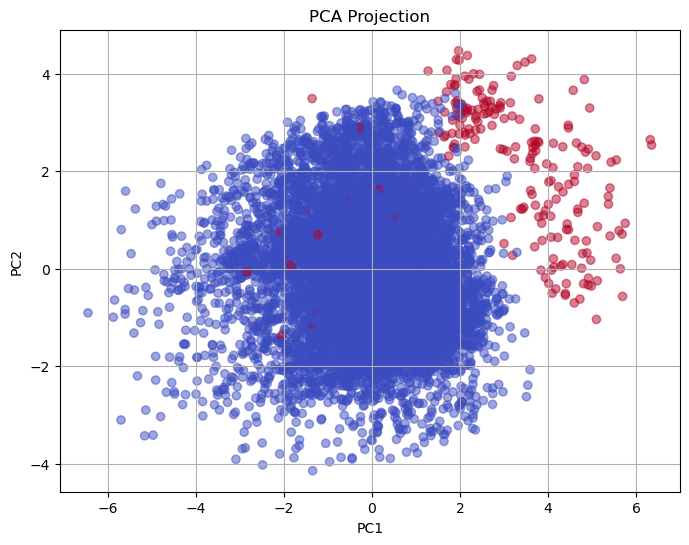

In [88]:
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


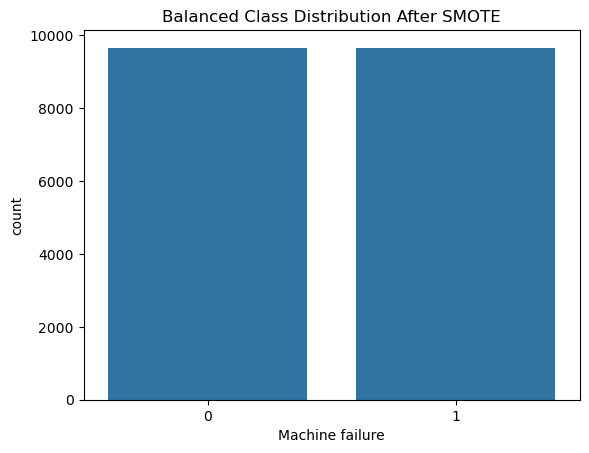

In [92]:
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_pca, y)

# Class distribution after SMOTE
sns.countplot(x=y_bal)
plt.title("Balanced Class Distribution After SMOTE")
plt.show()


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)


In [96]:
models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=500),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}



=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1943
           1       1.00      0.99      0.99      1921

    accuracy                           0.99      3864
   macro avg       0.99      0.99      0.99      3864
weighted avg       0.99      0.99      0.99      3864



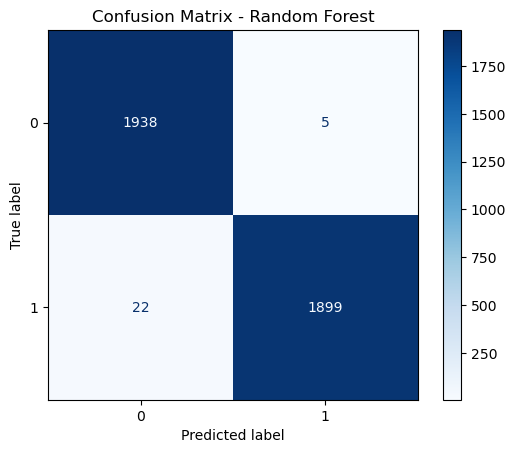


=== SVM ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1943
           1       1.00      0.96      0.98      1921

    accuracy                           0.98      3864
   macro avg       0.98      0.98      0.98      3864
weighted avg       0.98      0.98      0.98      3864



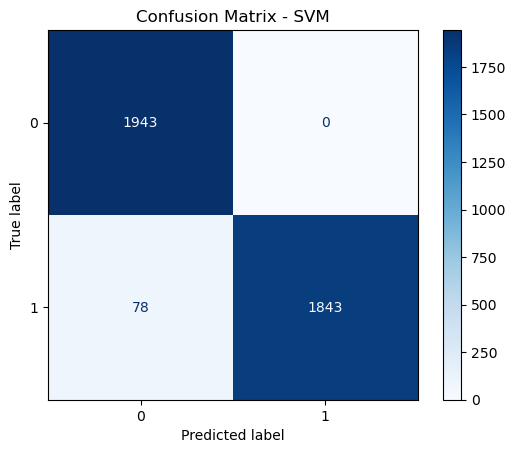


=== MLP ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1943
           1       1.00      0.99      0.99      1921

    accuracy                           0.99      3864
   macro avg       0.99      0.99      0.99      3864
weighted avg       0.99      0.99      0.99      3864



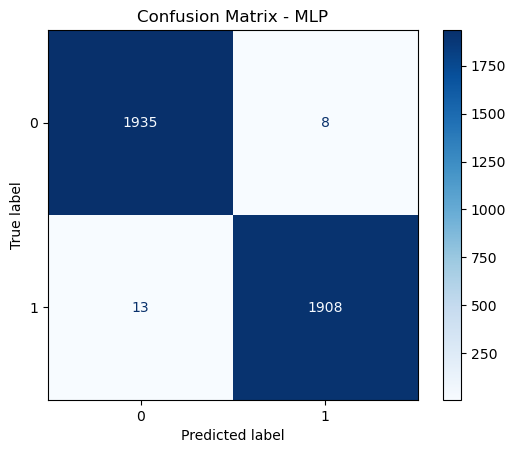


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1943
           1       1.00      0.99      0.99      1921

    accuracy                           0.99      3864
   macro avg       0.99      0.99      0.99      3864
weighted avg       0.99      0.99      0.99      3864



C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:26:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


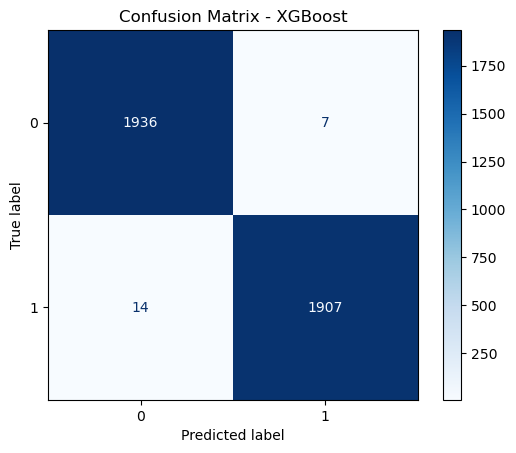

In [99]:
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Print metrics
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()


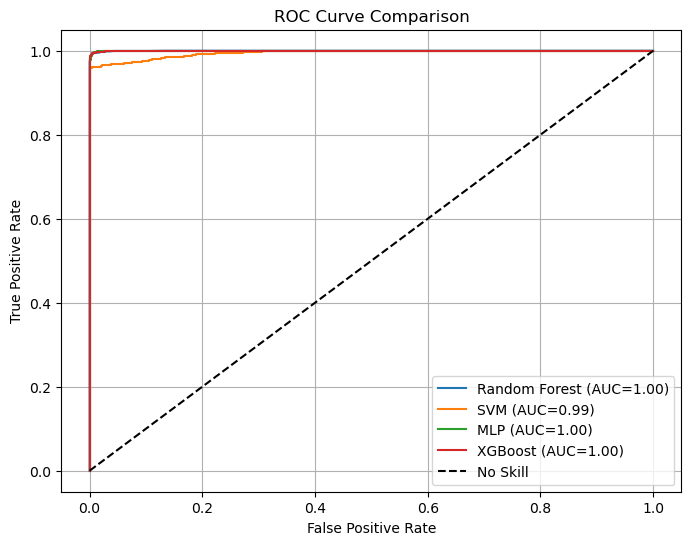

In [100]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


C:\Users\hp\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:26:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


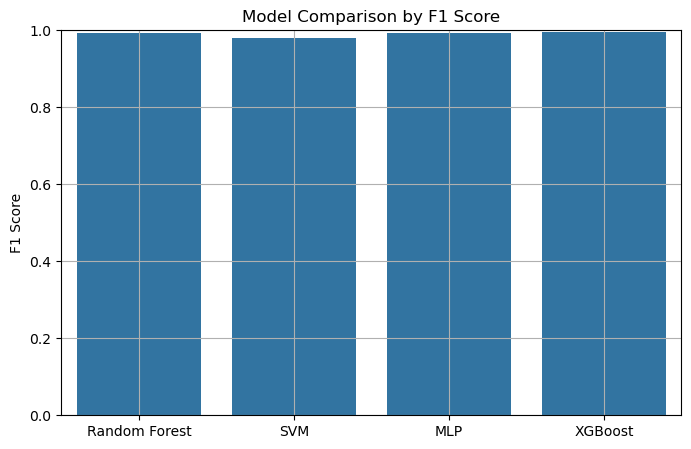

In [102]:
f1_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1_scores[name] = f1_score(y_test, y_pred)

plt.figure(figsize=(8, 5))
sns.barplot(x=list(f1_scores.keys()), y=list(f1_scores.values()))
plt.title("Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


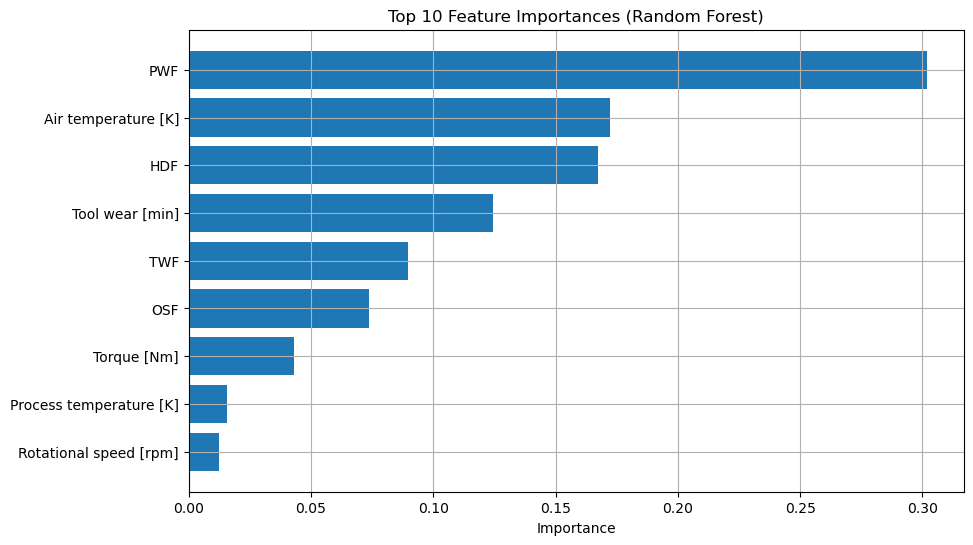

In [106]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.grid(True)
plt.show()


In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Drop ID columns
df.drop(columns=["UDI", "Product ID"], inplace=True)

# Convert target to binary
df['Machine failure'] = df['Machine failure'].astype(int)

# One-hot encode categorical
df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
df = pd.read_csv("ai4i2020.csv")
df = df.drop(columns=["UDI", "Product ID"])
df["Type"] = df["Type"].map({"L": 0, "M": 1, "H": 2})
iso = IsolationForest(contamination=0.01, random_state=42)
mask = iso.fit_predict(df.drop("Machine failure", axis=1)) == 1
df_clean = df[mask]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean.drop("Machine failure", axis=1))
y = df_clean["Machine failure"]
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X_pca, y)

#  Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

#  Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "MLP": MLPClassifier(max_iter=500, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

#  Model evaluation loop
results = {}
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    results[name] = (f1, auc)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
    print(f"{name} → F1 Score: {f1:.2f}, AUC: {auc:.2f}")

#  ROC curve plot
plt.plot([0, 1], [0, 1], 'k--', label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

#  Feature importance from Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
features = [f"PC{i+1}" for i in range(len(importances))]

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("rf_feature_importance.png")
plt.show()

#  Confusion matrix for XGBoost
xgb_model = models["XGBoost"]
cm = confusion_matrix(y_test, xgb_model.predict(X_test))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("xgb_confusion_matrix.png")
plt.show()

#  Output summary
summary_df = pd.DataFrame(results, index=["F1 Score", "AUC"]).T
print("\nModel Performance Summary:\n", summary_df.round(2))

